In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../')

from minilearn.classifiers import DecisionTree as MiniDT
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#load saved data
train_df = pd.read_csv('../data/train_features.csv')
test_df = pd.read_csv('../data/test_features.csv')

#seperate featuer and labels
feature_col = [col for col in train_df.columns if col != 'emotion']

X_train = train_df[feature_col].values
y_train = train_df['emotion'].values

X_test = test_df[feature_col].values
y_test = test_df['emotion'].values

#fix featul label space issue
y_train = np.array([label.strip() for label in y_train])
y_test = np.array([label.strip() for label in y_test])

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Classes: {np.unique(y_train)}")


Training set: (1961, 112)
Test set: (491, 112)
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [2]:
print("training MiniLearn Decision Tree")
mini_dt = MiniDT(max_depth=10, min_samples_split=2)
mini_dt.fit(X_train, y_train)
mini_dt_preds = mini_dt.predict(X_test)
mini_dt_acc = accuracy_score(y_test, mini_dt_preds)
print(f"MiniLearn Decision Tree Accuracy: {mini_dt_acc:.4f}")

training MiniLearn Decision Tree
MiniLearn Decision Tree Accuracy: 0.3890


IF I HAVE TIME GO BACK AND CHANGE 
col = X[:, feature]
thresholds = np.linspace(col.min(), col.max(), 10)
back to thresholds = np.unique(X[:, feature]) to get more accurate results!!!

In [4]:
print('Training Sklearn Decision Tree')
sklearn_dt = DecisionTreeClassifier(max_depth=10, random_state =42)
sklearn_dt.fit(X_train, y_train)
sklearn_dt_preds = sklearn_dt.predict(X_test)
sklearn_dt_acc = accuracy_score(y_test, sklearn_dt_preds)
print(f"Sklearn Decision Tree Accuracy: {sklearn_dt_acc:.4f}")

print("\nTraining Random Forest")
sklearn_rf = RandomForestClassifier(n_estimators=100, random_state=42)
sklearn_rf.fit(X_train,y_train)
sklearn_rf_preds = sklearn_rf.predict(X_test)
sklearn_rf_acc = accuracy_score(y_test, sklearn_rf_preds)
print(f"Random Forest Accuracy: {sklearn_rf_acc:.4f}")

print("\nTraining AdaBoost")
sklearn_ada = AdaBoostClassifier(n_estimators=100, random_state=42)
sklearn_ada.fit(X_train, y_train)
sklearn_ada_pred= sklearn_ada.predict(X_test)
sklearn_ada_acc = accuracy_score(y_test, sklearn_ada_pred)
print(f"AdaBoost Accuracy: {sklearn_ada_acc:.4f}")



Training Sklearn Decision Tree
Sklearn Decision Tree Accuracy: 0.4175

Training Random Forest
Random Forest Accuracy: 0.6477

Training AdaBoost
AdaBoost Accuracy: 0.3951


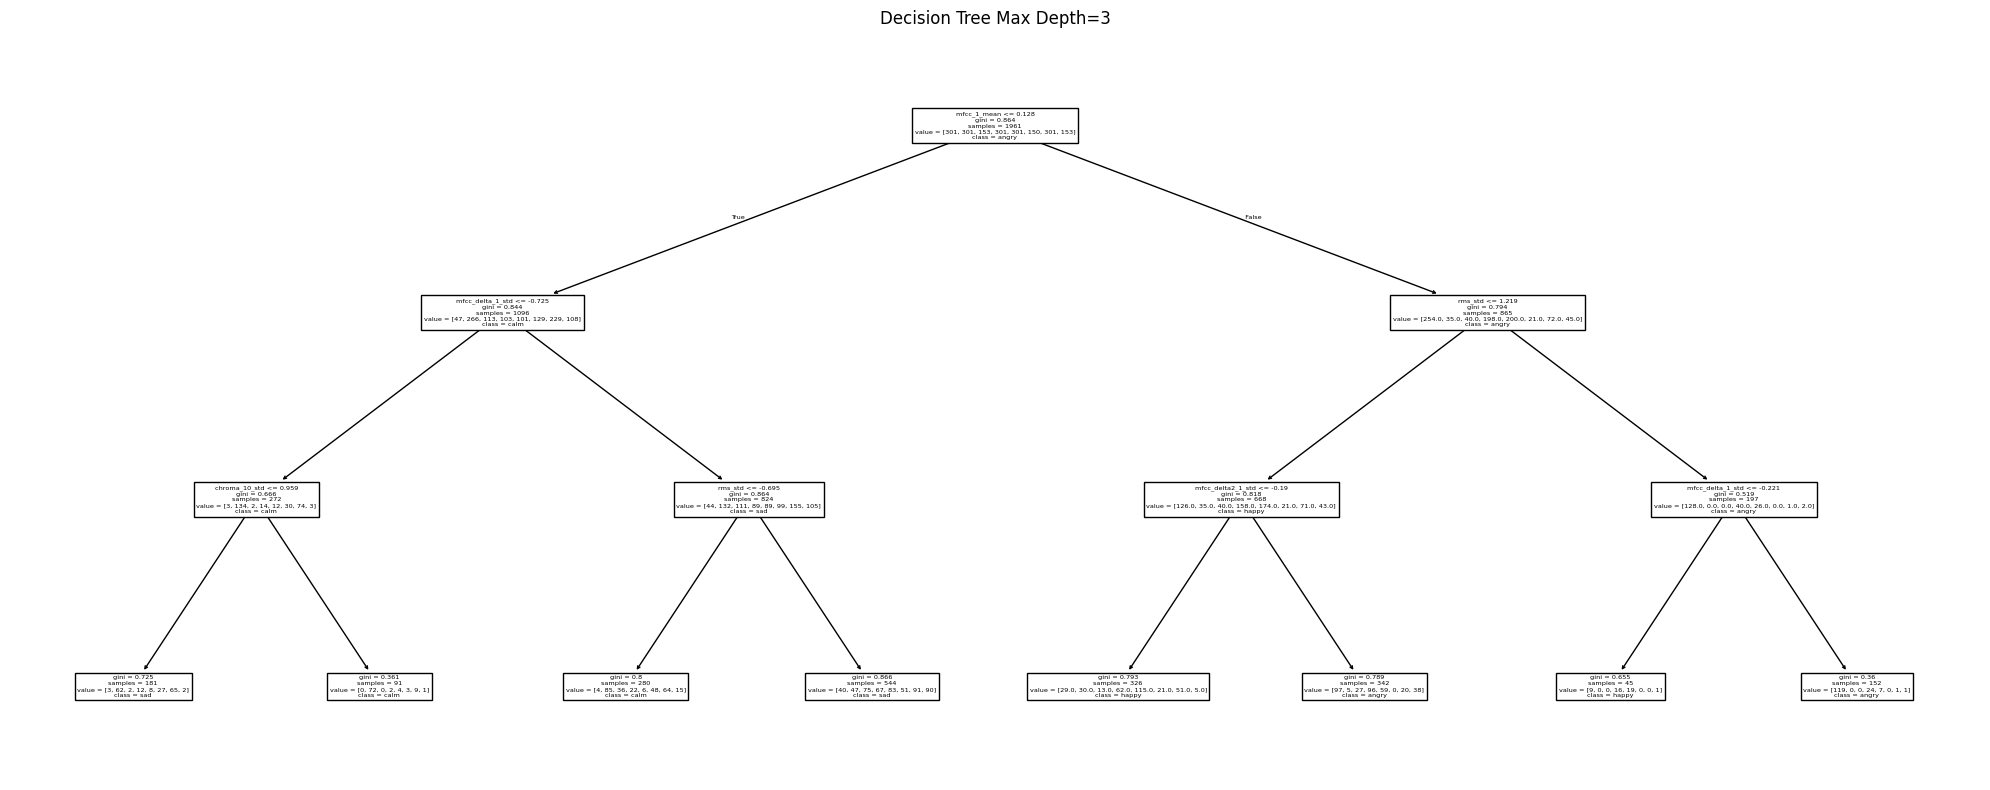

In [5]:
#Visualize the decision treee
shallow_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
shallow_dt.fit(X_train,y_train)
plt.figure(figsize=(20,8))
plot_tree(shallow_dt, feature_names=feature_col, class_names=np.unique(y_train))
plt.title("Decision Tree Max Depth=3")
plt.tight_layout()
plt.show()

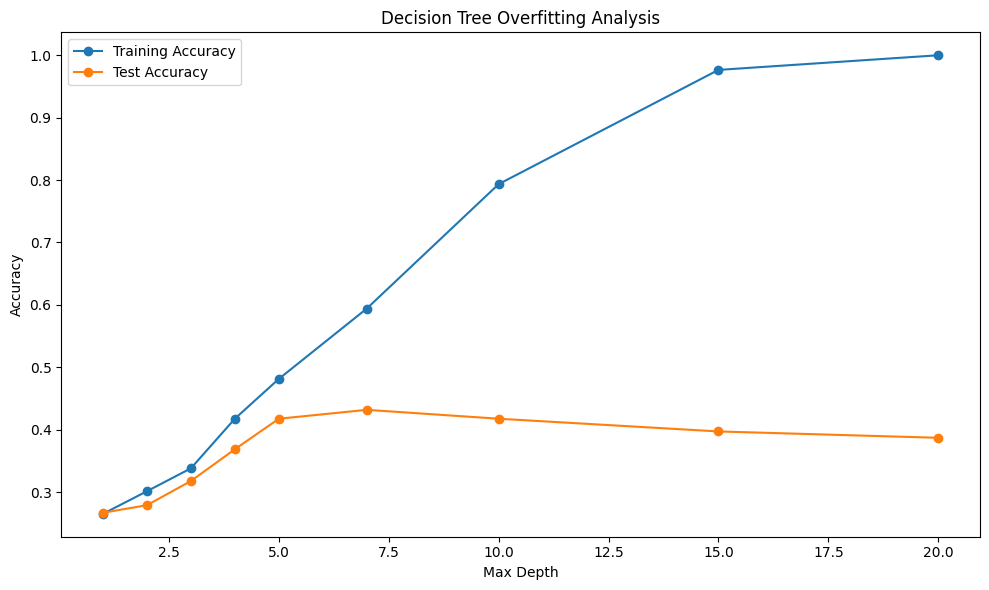

In [6]:
#check overfitting by comparing train vs test accurcy at differnt depths
depths=[1, 2, 3, 4, 5, 7, 10, 15, 20]
train_accs = []
test_accs = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt.predict(X_train)))
    test_accs.append(accuracy_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(10,6))
plt.plot(depths, train_accs, label="Training Accuracy", marker='o')
plt.plot(depths, test_accs, label="Test Accuracy", marker='o')
plt.xlabel('Max Depth')
plt.ylabel("Accuracy")
plt.title("Decision Tree Overfitting Analysis")
plt.legend()
plt.tight_layout()
plt.show()




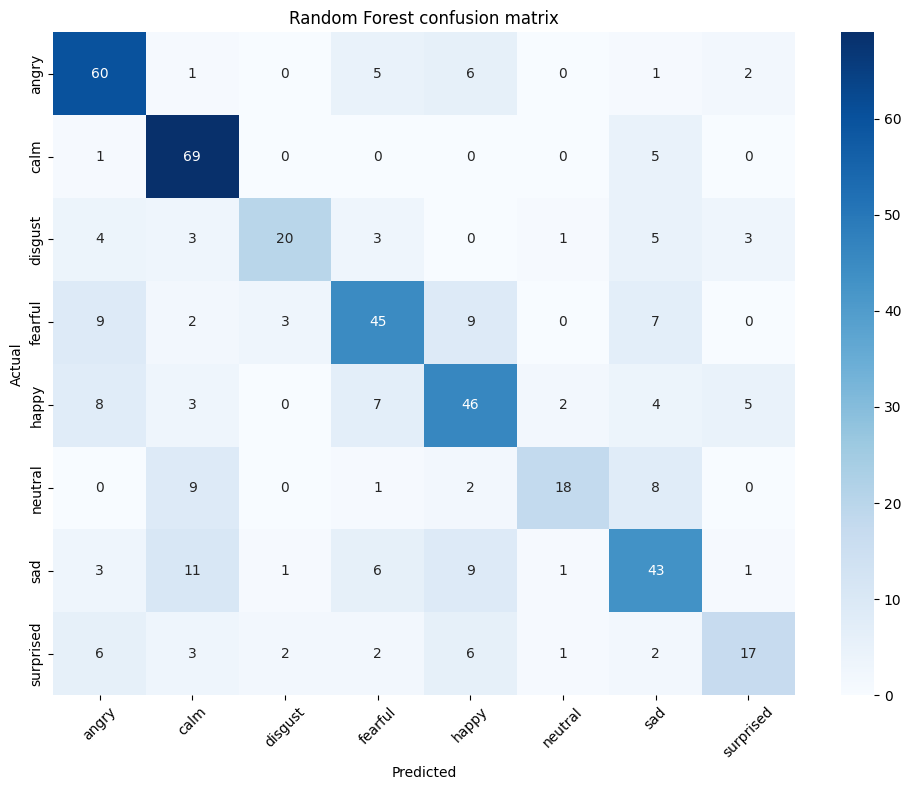

random Forest Classification Report
              precision    recall  f1-score   support

       angry       0.66      0.80      0.72        75
        calm       0.68      0.92      0.78        75
     disgust       0.77      0.51      0.62        39
     fearful       0.65      0.60      0.62        75
       happy       0.59      0.61      0.60        75
     neutral       0.78      0.47      0.59        38
         sad       0.57      0.57      0.57        75
   surprised       0.61      0.44      0.51        39

    accuracy                           0.65       491
   macro avg       0.66      0.62      0.63       491
weighted avg       0.65      0.65      0.64       491



In [7]:
plt.figure(figsize=(10,8))
cm=confusion_matrix(y_test, sklearn_rf_preds, labels=np.unique(y_test))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Random Forest confusion matrix')
plt.xlabel('Predicted')
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("random Forest Classification Report")
print(classification_report(y_test, sklearn_rf_preds))
